In [2]:
#Installing necessary libraries

%pip install control > NUL
%pip install matplotlib > NUL
%pip install numpy > NUL

In [3]:
import control as ctrl
from math import exp, sqrt, sin
import matplotlib.pyplot as plt
import numpy as np

s = ctrl.TransferFunction.s

m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c_val = 6.811
k = 1885
b = 10.4
tau = 0.03
phi = np.deg2rad(41)

x_1e = 0.5
x_2e = 0
x_3e = (delta - x_1e)*sqrt( (k*(x_1e-d) - m*g*sin(phi)) / c_val)


a_3 = (5/(7*m)) * (2*c_val*x_3e)/((delta - x_1e)**2) #x3
a_2 = (5/(7*m))*(-b) #x2
a_1 = (5/(7*m)) * ( (2*c_val*(x_3e**2) ) / ( (delta - x_1e)**3 )  -k) #x1

b_1 = 1/ (L0 + L1*exp(-alpha*(delta - x_1e)))
b_2 = -R/ (L0 + L1*exp(-alpha*(delta - x_1e)))

Gm = a_3/(s**2 - a_2*s - a_1)
Ge = b_1/(s - b_2)
Gs = (1)/((tau*s)+1)

Gme = Gm*Ge

Finding $K_p$

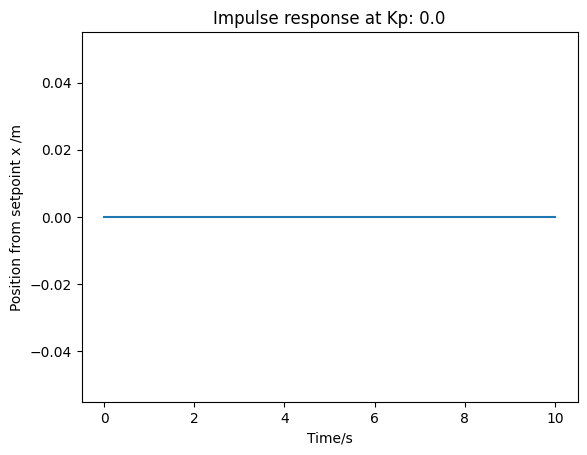

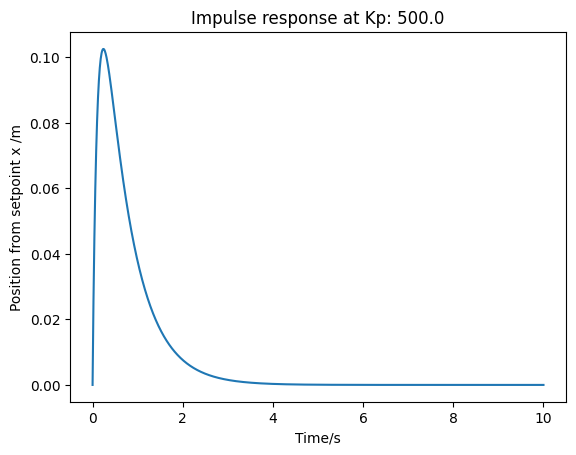

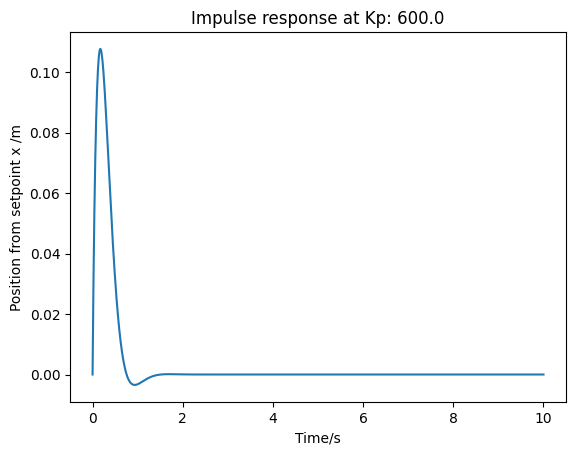

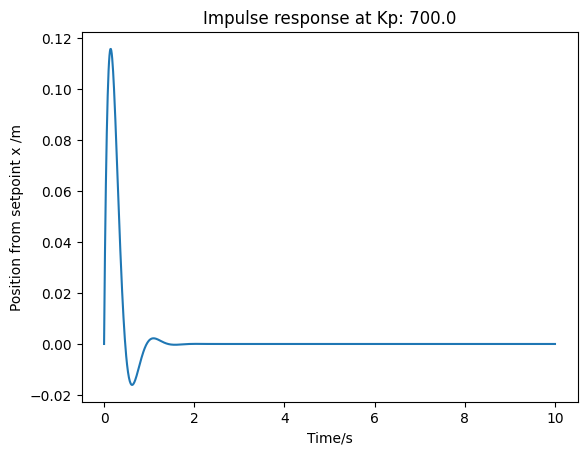

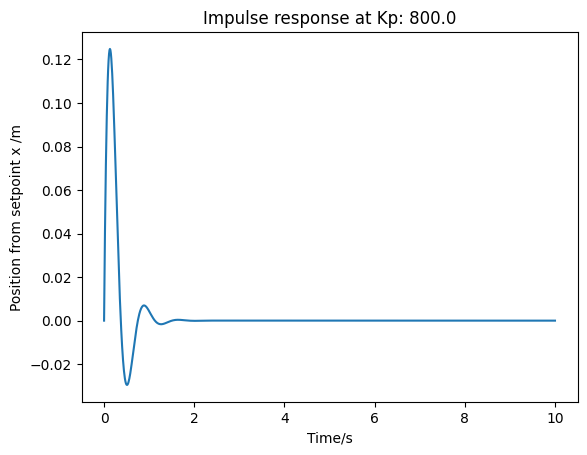

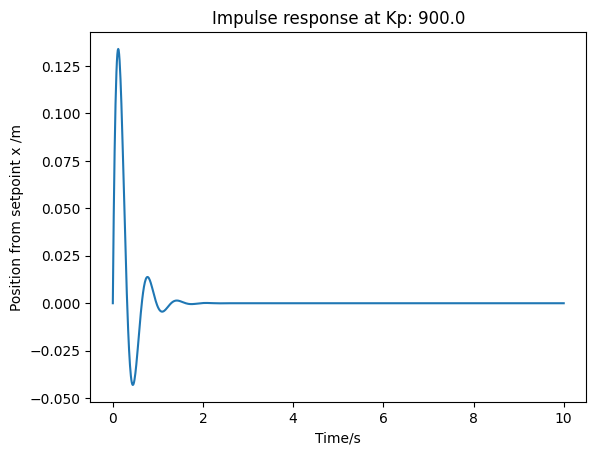

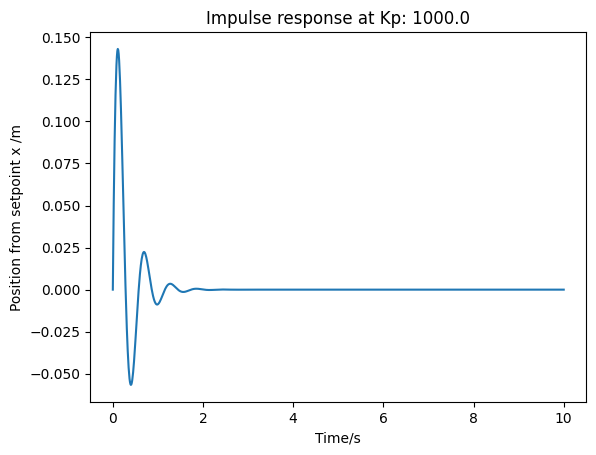

In [4]:
#Finding stable Kp's through an iterative process

Kp = 0
Kd = 0
Ki = 0

for Kp in [n for n in np.linspace(0,1000,11)]:

  Gc = Kp + Ki/s + Kd*s
  Gload = ctrl.feedback(Gme*Gc, Gs)

  poles = ctrl.poles(Gload)

  if all(pole.real < 0 for pole in poles):
    time,xs = ctrl.impulse_response(Gload, timepts=np.linspace(0, 10, 1000))
    plt.plot(time, xs*0.01)
    plt.title(f"Impulse response at Kp: {Kp}")
    plt.xlabel("Time/s")
    plt.ylabel("Position from setpoint x /m")
    plt.show()

A $K_p$ value of 700 is chosen

Finding $K_d$

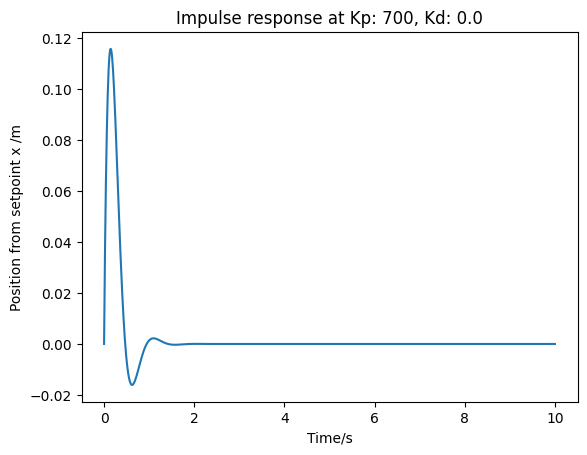

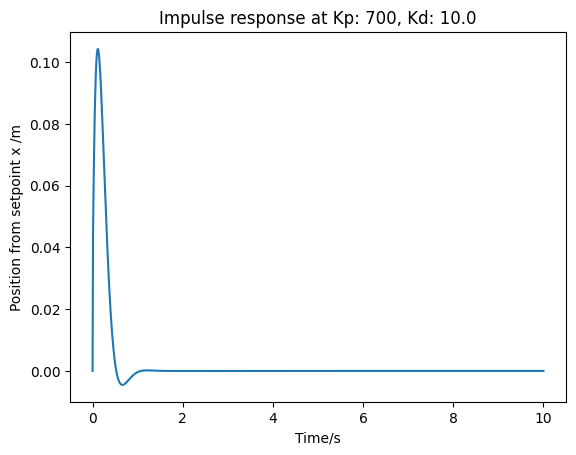

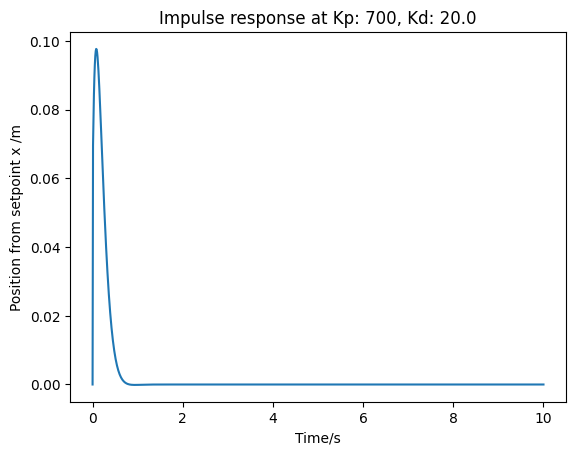

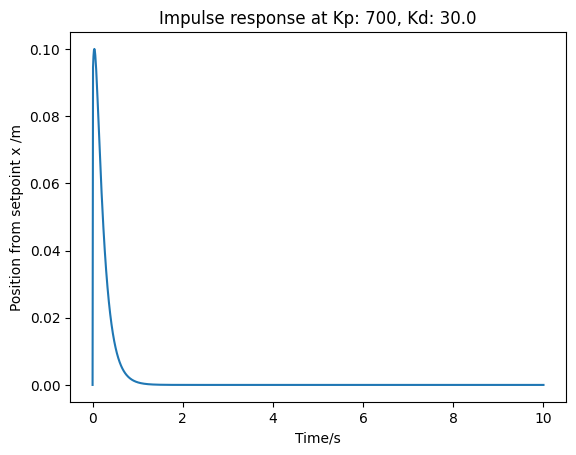

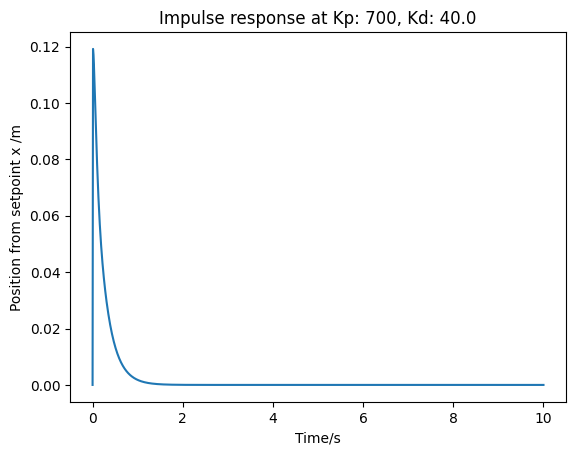

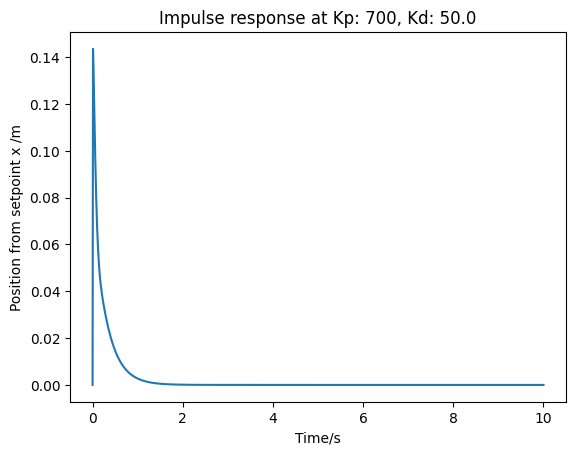

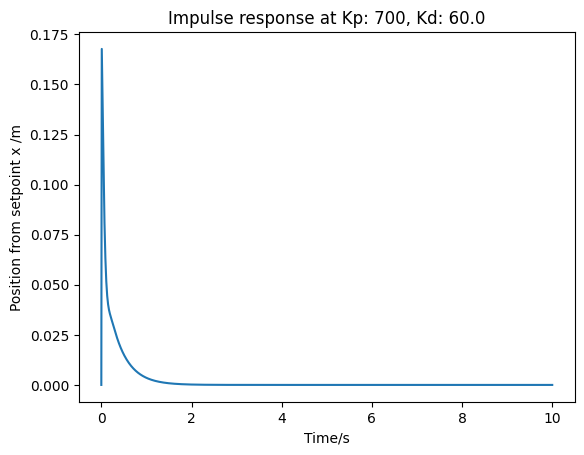

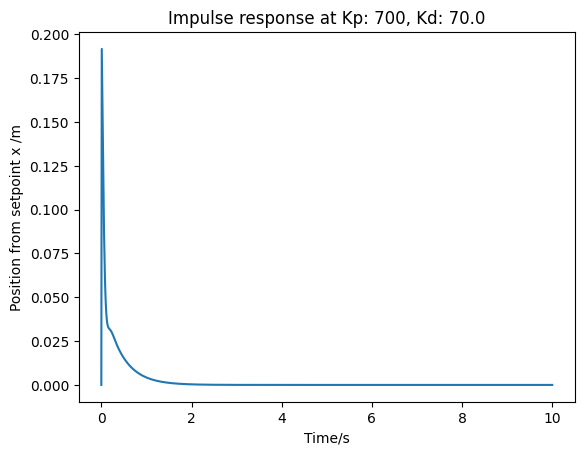

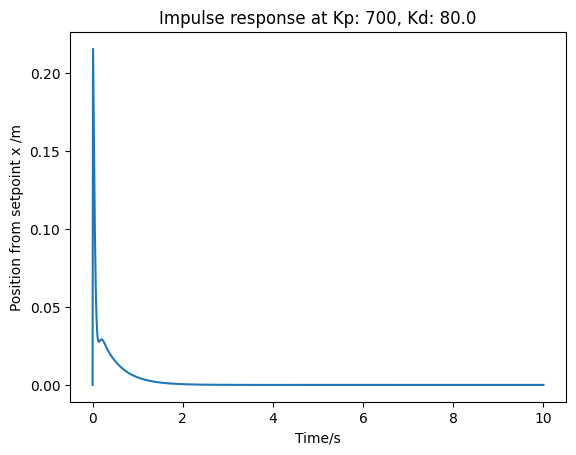

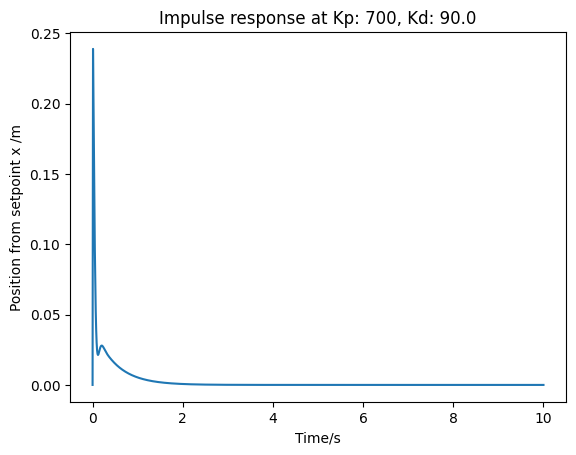

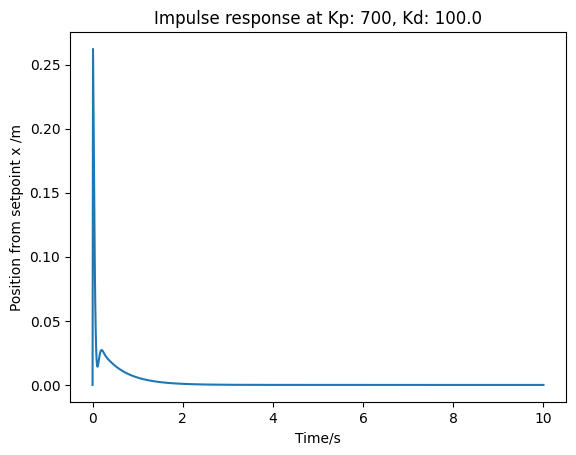

In [5]:
#Finding stable Kd's

Kp = 700
Kd = 0
Ki = 0

for Kd in [n for n in np.linspace(0,100,11)]:

  Gc = Kp + Ki/s + Kd*s
  Gload = ctrl.feedback(Gme*Gc, Gs)

  poles = ctrl.poles(Gload)

  if all(pole.real < 0 for pole in poles):
    time,xs = ctrl.impulse_response(Gload, timepts=np.linspace(0, 10, 1000))
    plt.plot(time, xs*0.01)
    plt.title(f"Impulse response at Kp: {Kp}, Kd: {Kd}")
    plt.xlabel("Time/s")
    plt.ylabel("Position from setpoint x /m")
    plt.show()

A $K_d$ value of 20 is chosen


Impulse responses have already been tested; step response must be tested in order to determine if an integral component is needed

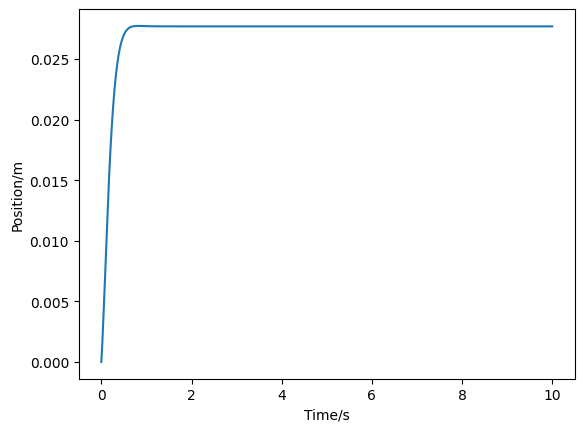

In [6]:
#Step response

Kp = 700
Kd = 20
Ki = 0

Gc = Kp + Ki/s + Kd*s
Gload = ctrl.feedback(Gme*Gc, Gs)

time,xs = ctrl.step_response(Gload, timepts=np.linspace(0, 10, 1000))
plt.plot(time, xs*0.01)
plt.xlabel("Time/s")
plt.ylabel("Position/m")
plt.show()

Finding $K_i$

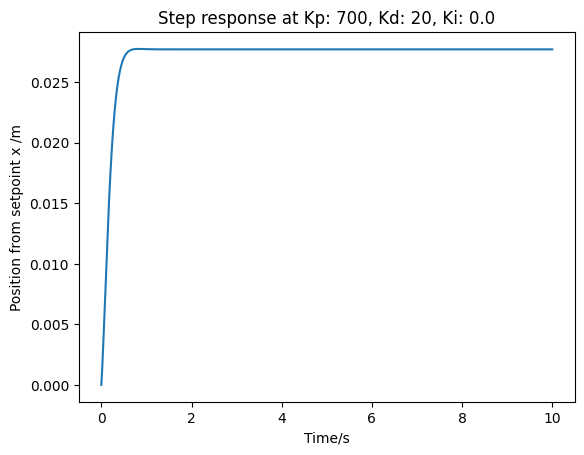

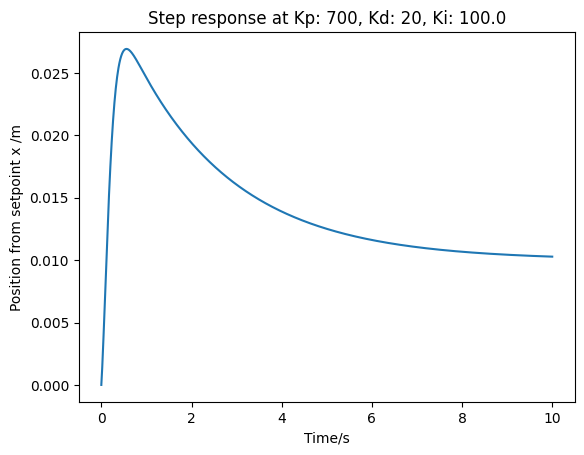

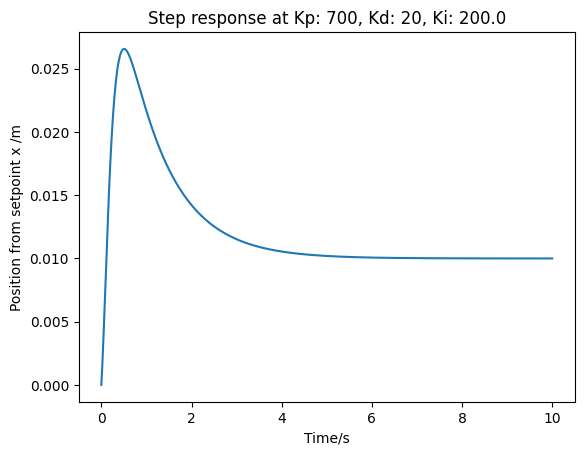

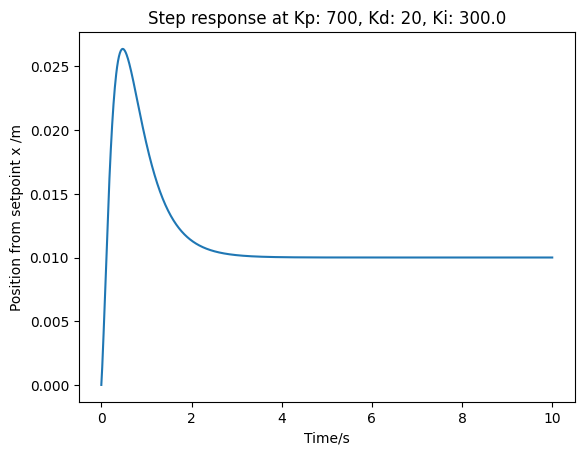

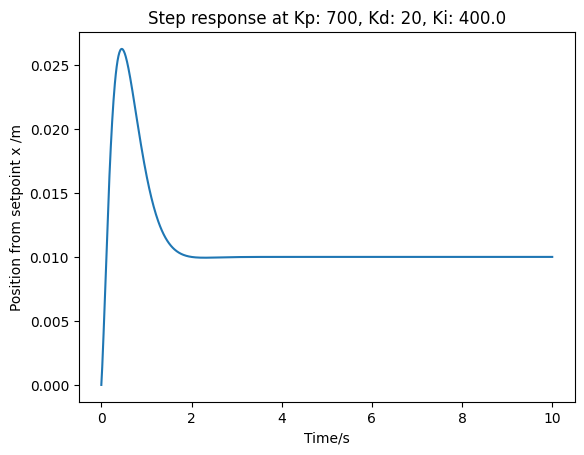

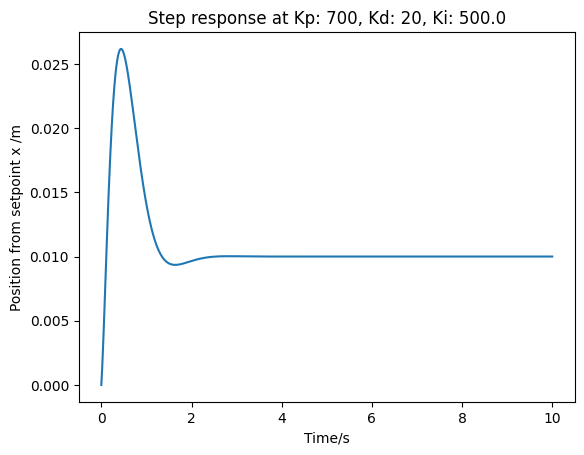

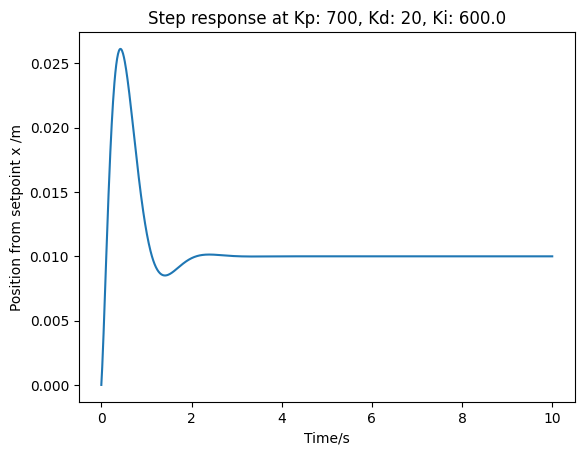

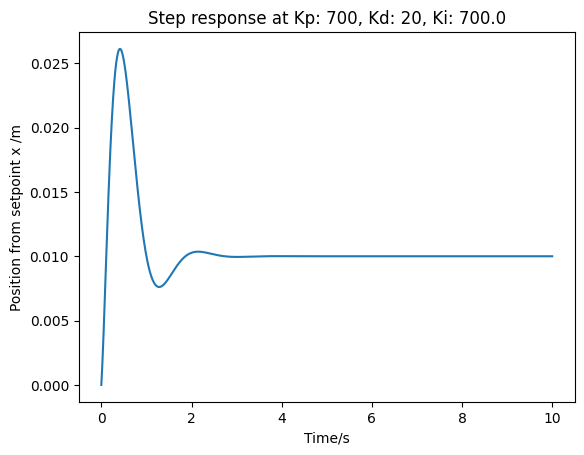

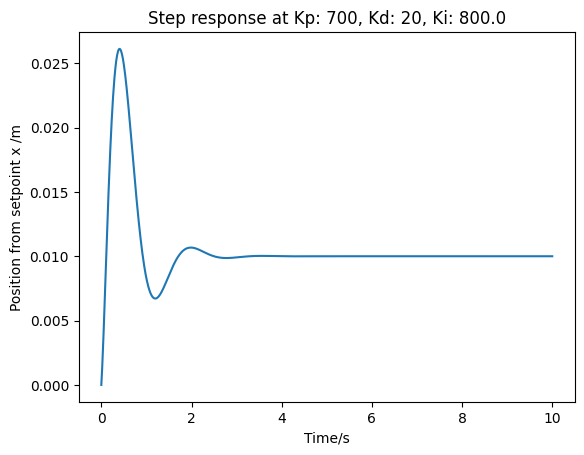

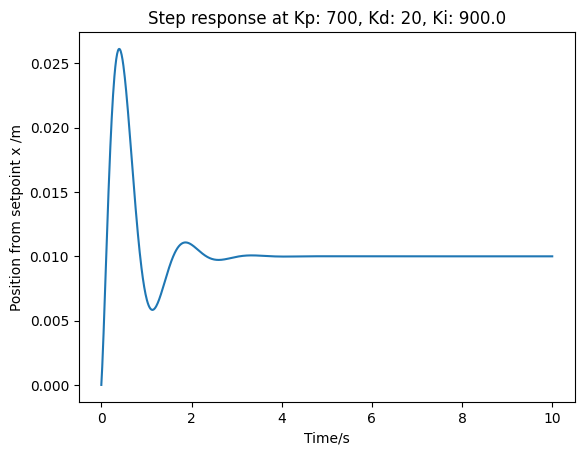

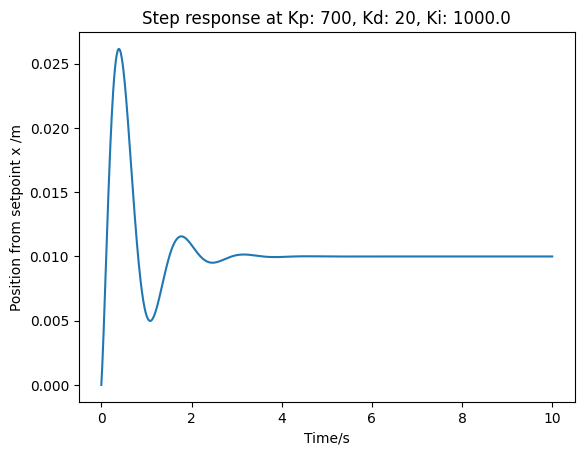

In [7]:
Kp = 700
Kd = 20
Ki = 0

for Ki in [n for n in np.linspace(0,1000,11)]:

  Gc = Kp + Ki/s + Kd*s
  Gload = ctrl.feedback(Gme*Gc, Gs)

  poles = ctrl.poles(Gload)

  if all(pole.real < 0 for pole in poles):
    time,xs = ctrl.step_response(Gload, timepts=np.linspace(0, 10, 1000))
    xs_scaled = xs*0.01
    plt.plot(time, xs_scaled)
    plt.title(f"Step response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
    plt.xlabel("Time/s")
    plt.ylabel("Position from setpoint x /m")
    plt.show()

A $K_i$ value of 400 is chosen

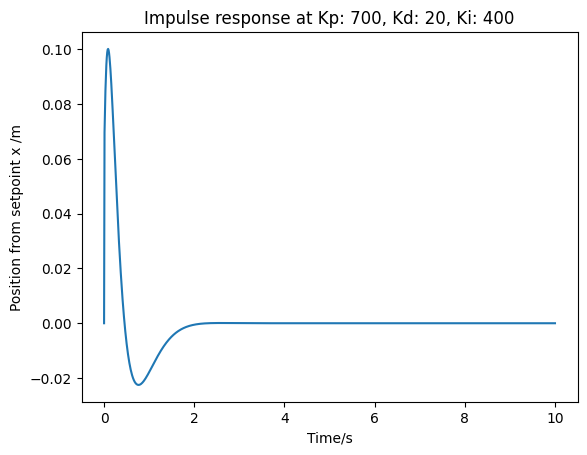

Max: 0.100 m 
Min: -0.023 m
Maximum overshoot: 4.506%


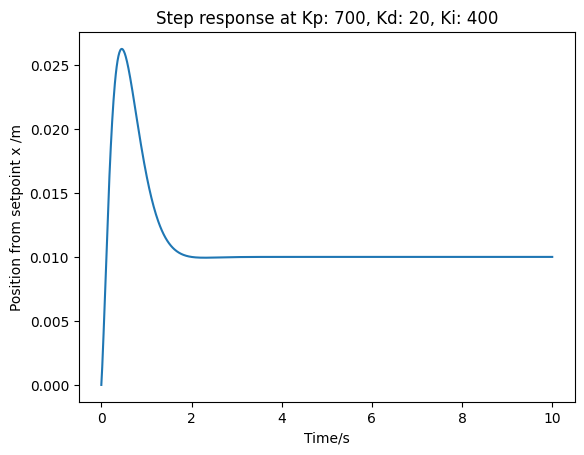

Max: 0.0262 m 
Min: 0.0000 m
Maximum overshoot: 5.2495%


Poles:
(-15158.83494908464+0j)
(-33.657457925148194+0j)
(-9.66923569603355+0j)
(-3.0363551680186456+1.720993985091934j)
(-3.0363551680186456-1.720993985091934j)

Stable!


In [8]:
#Testing Impulse and step responses of our completed controller

Kp = 700
Kd = 20
Ki = 400

Gc = Kp + Ki/s + Kd*s
Gload = ctrl.feedback(Gme*Gc, Gs)

#Impulse response

time,xs = ctrl.impulse_response(Gload, timepts=np.linspace(0, 10, 1000))
xs_scaled = xs*0.01
plt.plot(time, xs_scaled)
plt.title(f"Impulse response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
plt.xlabel("Time/s")
plt.ylabel("Position from setpoint x /m")
plt.savefig("impulse_response_PID.eps")
plt.show()

impulse_response_max_value = max(xs_scaled)
impulse_response_min_value = min(xs_scaled)
impulse_response_max_overshoot = abs(impulse_response_min_value )

print(f"Max: {impulse_response_max_value:.3f} m \nMin: {impulse_response_min_value:.3f} m")
print(f"Maximum overshoot: {(impulse_response_max_overshoot / x_1e)*100:.3f}%")


#step response

time,xs = ctrl.step_response(Gload, timepts=np.linspace(0, 10, 1000))
xs_scaled = xs*0.01
plt.plot(time, xs_scaled)
plt.title(f"Step response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
plt.xlabel("Time/s")
plt.ylabel("Position from setpoint x /m")
plt.savefig("step_response_PID.eps")
plt.show()

step_response_max_value = max(xs_scaled)
step_response_min_value = min(xs_scaled)
step_response_max_overshoot = max( abs(step_response_max_value) , abs(step_response_min_value) )

print(f"Max: {step_response_max_value:.4f} m \nMin: {step_response_min_value:.4f} m")
print(f"Maximum overshoot: {(step_response_max_overshoot / x_1e)*100:.4f}%\n\n")


#verification of stability

poles = ctrl.poles(Gload)
print("Poles:")
for pole in poles:
  print(pole)

if all(pole.real < 0 for pole in poles):
  print("\nStable!")



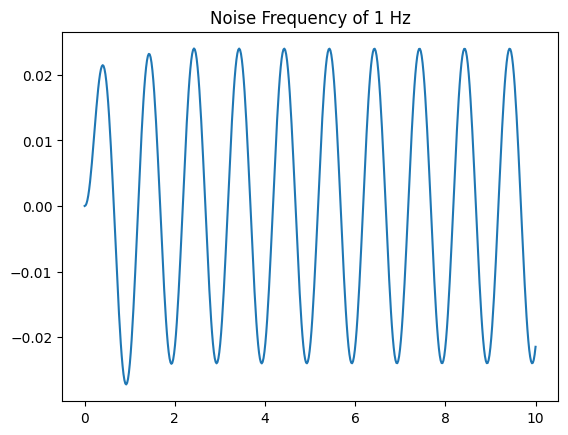

Amplitude: 0.024


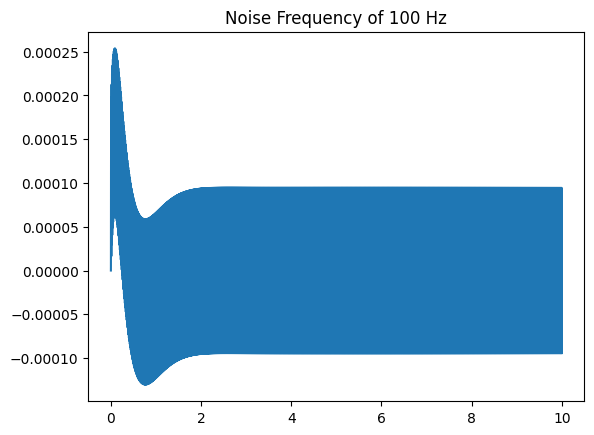

Amplitude: 0.000


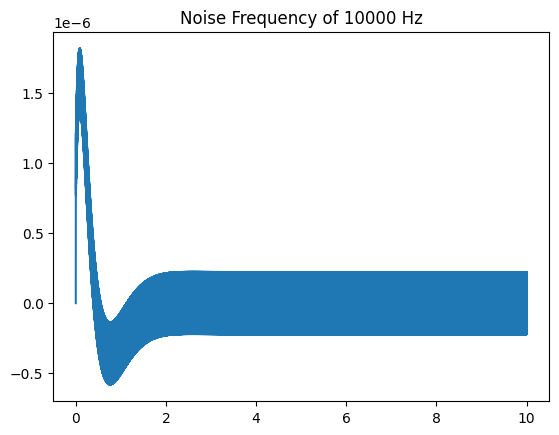

Amplitude: 0.000


In [9]:
Kp = 700
Kd = 20
Ki = 400

Gc = Kp + Ki/s + Kd*s
Gload = ctrl.feedback(Gme*Gc, Gs)

for i in range(3):
  freq = 100**i

  time = np.linspace(0,10,500*freq)
  F = np.sin(2*np.pi*freq * time)

  response = ctrl.forced_response(Gload, time, F)
  plt.plot(response.time , (response.outputs*0.01))
  plt.title(f"Noise Frequency of {freq} Hz")
  plt.savefig(f"noise_respone_{freq}Hz.eps")
  plt.show()

  print(f"Amplitude: {max(response.outputs * 0.01):.3f}")

Amplitudes are only ≈ 0.004m, or 0.8% deviation from the setpoint, so I think this is acceptable

In [ ]:
G_open_loop_with_controller = Gme*Gc*Gs

poles = ctrl.poles(G_open_loop_with_controller)

for pole in poles:
    if pole.real < 0:
        print(pole)
    elif pole.real == 0:
        print(f"{pole} <-- Marginally stable pole")
    else:
        print(f"{pole} <-- Unstable pole")

(-15158.821860772234+0j)
(-33.33333333333341+0j)
(-22.097673838309735+0j)
(6.018514902008066+0j) <-- Unstable pole
0j <-- Marginally stable pole
